In [ ]:
import torch
import torch.optim as optim
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader
from torchsummary import summary
import numpy as np
import pandas as pd
import statistics
from openpyxl import Workbook, load_workbook
import os
import random
import matplotlib

In [2]:
from data.audio_preprocessor import AudioPreprocessor
from data.speech_commands_ds import SpeechCommandsDataset
from nets.vgg import VGG1D
from model.training import train_model, plot_training_history, plot_combined_training_history
from model.testing import test_model

In [3]:
# experiments
# 	1d_vgg
# 		summary.xlsx
# 		lr_001
# 			rs_42
# 				analysis.txt
# 				trainig_history.pdf
# 				confusion_matrix.pdf
# 				confusion_matrix_norm.pdf
# 			rs_24
# 			training_history.pdf
# 		lr_01
# 		epochs20

In [4]:
# Base configuration with default values
base_config = {
    'data_dir': 'C:/Users/weron/Pulpit/sem1/dl/proj1/Deep-Learning/transformers/dataset/train',
    'model_type': '1d',
    'model_name': 'vgg',
    'device': torch.device('cuda' if torch.cuda.is_available() else 'cpu'),
    'batch_size': 32,          
    'num_epochs': 20,         
    'learning_rate': 0.001,    
    'weight_decay': 0.0001,    
    'title': 'base'
}

experiment_configs = []
experiment_configs.append(base_config)

# Varying batch sizes
batch_sizes = [16, 64, 128]
for bs in batch_sizes:
    config = base_config.copy()
    config.update({
        'batch_size': bs,
        'title': f'batch_{bs}'
    })
    experiment_configs.append(config)

# Varying learning rates
learning_rates = [0.1, 0.01, 0.0001]
for lr in learning_rates:
    config = base_config.copy()
    config.update({
        'learning_rate': lr,
        'title': f'lr_{lr}'
    })
    experiment_configs.append(config)

# Varying weight decay
weight_decays = [0.1, 0.01, 0.001]
for wd in weight_decays:
    config = base_config.copy()
    config.update({
        'weight_decay': wd,
        'title': f'wd_{wd}'
    })
    experiment_configs.append(config)

# Varying epoch counts
epoch_counts = [10, 50, 100]
for epochs in epoch_counts:
    config = base_config.copy()
    config.update({
        'num_epochs': epochs,
        'title': f'epochs_{epochs}'
    })
    experiment_configs.append(config)

Epoch 0/19
----------
train Loss: 1.8095 Acc: 0.4646
valid Loss: 1.4289 Acc: 0.5210

Epoch 1/19
----------
train Loss: 0.7765 Acc: 0.7499
valid Loss: 0.9641 Acc: 0.7091

Epoch 2/19
----------
train Loss: 0.6322 Acc: 0.8163
valid Loss: 1.4857 Acc: 0.5670

Epoch 3/19
----------
train Loss: 0.5572 Acc: 0.8435
valid Loss: 0.6861 Acc: 0.7792

Epoch 4/19
----------
train Loss: 0.5775 Acc: 0.8488
valid Loss: 0.5845 Acc: 0.8199

Epoch 5/19
----------
train Loss: 0.4114 Acc: 0.8833
valid Loss: 0.7600 Acc: 0.7528

Epoch 6/19
----------
train Loss: 0.4169 Acc: 0.8858
valid Loss: 0.5115 Acc: 0.8279

Epoch 7/19
----------
train Loss: 0.2305 Acc: 0.9343
valid Loss: 0.2321 Acc: 0.9284

Epoch 8/19
----------
train Loss: 0.2001 Acc: 0.9412
valid Loss: 0.2107 Acc: 0.9360

Epoch 9/19
----------
train Loss: 0.1861 Acc: 0.9457
valid Loss: 0.2015 Acc: 0.9392

Epoch 10/19
----------
train Loss: 0.1703 Acc: 0.9497
valid Loss: 0.2134 Acc: 0.9381

Epoch 11/19
----------
train Loss: 0.1597 Acc: 0.9533
valid Loss

C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_plot\confusion_matrix.py:140: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots()


Epoch 0/19
----------
train Loss: 1.9041 Acc: 0.4695
valid Loss: 1.2640 Acc: 0.5500

Epoch 1/19
----------
train Loss: 0.9228 Acc: 0.6901
valid Loss: 0.8807 Acc: 0.6920

Epoch 2/19
----------
train Loss: 0.6142 Acc: 0.8070
valid Loss: 0.7674 Acc: 0.7450

Epoch 3/19
----------
train Loss: 0.4633 Acc: 0.8613
valid Loss: 1.1176 Acc: 0.6810

Epoch 4/19
----------
train Loss: 0.4006 Acc: 0.8805
valid Loss: 0.5874 Acc: 0.8203

Epoch 5/19
----------
train Loss: 0.3599 Acc: 0.8965
valid Loss: 0.6237 Acc: 0.7967

Epoch 6/19
----------
train Loss: 0.3539 Acc: 0.8995
valid Loss: 0.4317 Acc: 0.8709

Epoch 7/19
----------
train Loss: 0.2077 Acc: 0.9392
valid Loss: 0.2169 Acc: 0.9353

Epoch 8/19
----------
train Loss: 0.1739 Acc: 0.9490
valid Loss: 0.2278 Acc: 0.9345

Epoch 9/19
----------
train Loss: 0.1596 Acc: 0.9527
valid Loss: 0.2134 Acc: 0.9379

Epoch 10/19
----------
train Loss: 0.1543 Acc: 0.9547
valid Loss: 0.2111 Acc: 0.9390

Epoch 11/19
----------
train Loss: 0.1443 Acc: 0.9580
valid Loss

C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Accuracy: 0.6207
Epoch 0/19
----------
train Loss: 202.9897 Acc: 0.2303
valid Loss: 4.1986 Acc: 0.4340

Epoch 1/19
----------
train Loss: 5.4837 Acc: 0.2579
valid Loss: 4785.9465 Acc: 0.4340

Epoch 2/19
----------
train Loss: 3.3205 Acc: 0.2923
valid Loss: 472.0056 Acc: 0.0571

Epoch 3/19
----------
train Loss: 2.7264 Acc: 0.3335
valid Loss: 2.2210 Acc: 0.4338

Epoch 4/19
----------
train Loss: 2.3518 Acc: 0.3962
valid Loss: 5.4193 Acc: 0.0554

Epoch 5/19
----------
train Loss: 2.1912 Acc: 0.4320
valid Loss: 2.0379 Acc: 0.4340

Epoch 6/19
----------
train Loss: 19.4118 Acc: 0.3898
valid Loss: 2.5737 Acc: 0.4340

Epoch 7/19
----------
train Loss: 2.3805 Acc: 0.4041
valid Loss: 2.0611 Acc: 0.4340

Epoch 8/19
----------
train Loss: 2.1350 Acc: 0.4402
valid Loss: 2.0615 Acc: 0.4340

Epoch 9/19
----------
train Loss: 2.0701 Acc: 0.4466
valid Loss: 2.0459 Acc: 0.4340

Epoch 10/19
----------
train Loss: 2.0417 Acc: 0.4479
valid Loss: 2.0392 Acc: 0.4340

Epoch 11/19
----------
train Loss: 2.03

C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\weron\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} i

Accuracy: 0.6207


FileNotFoundError: [Errno 2] No such file or directory: 'experiments\\1d_vgg\\lr_0.1\\training_history.pdf'

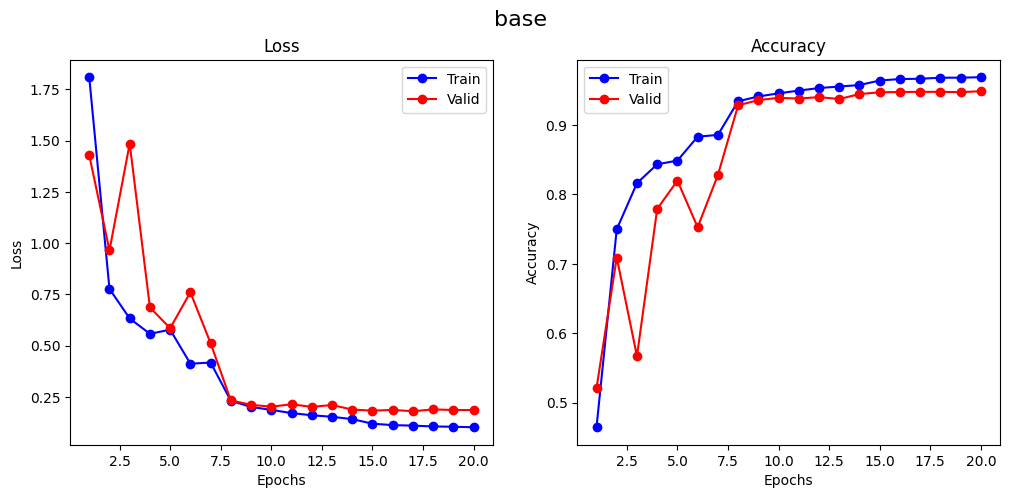

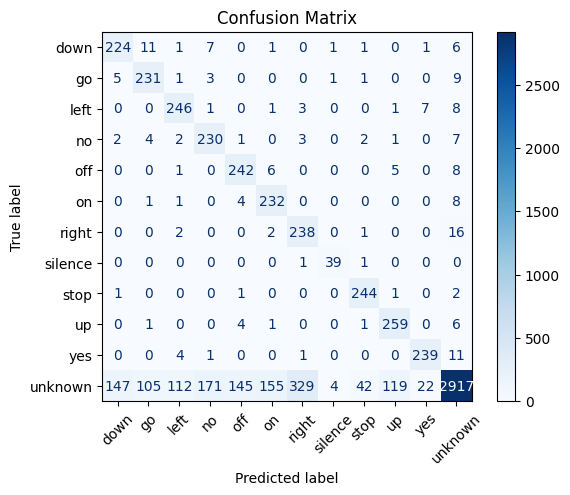

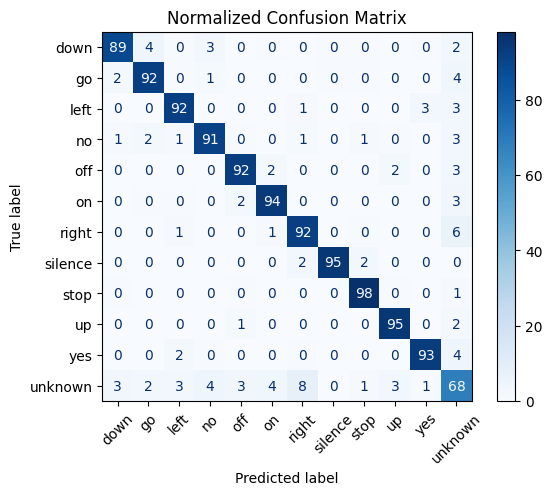

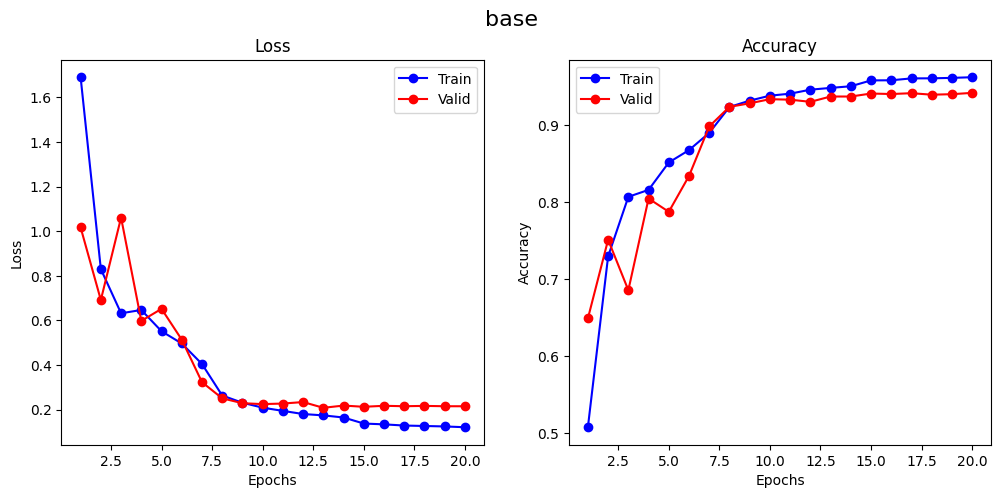

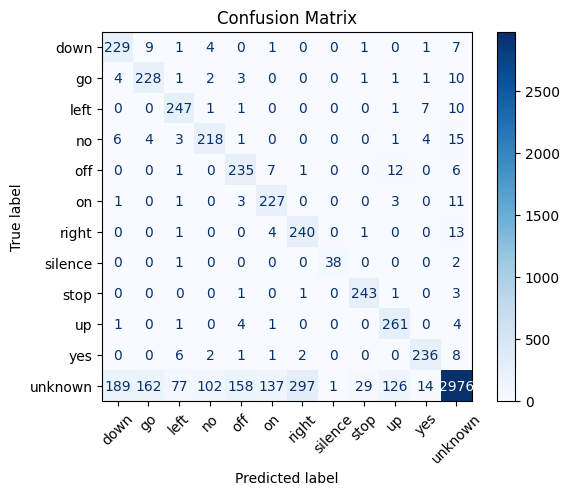

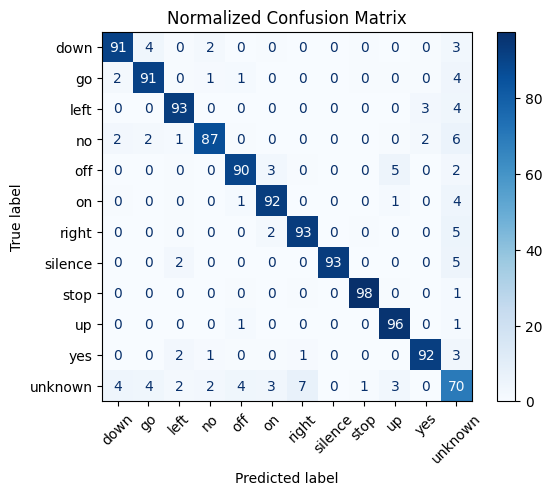

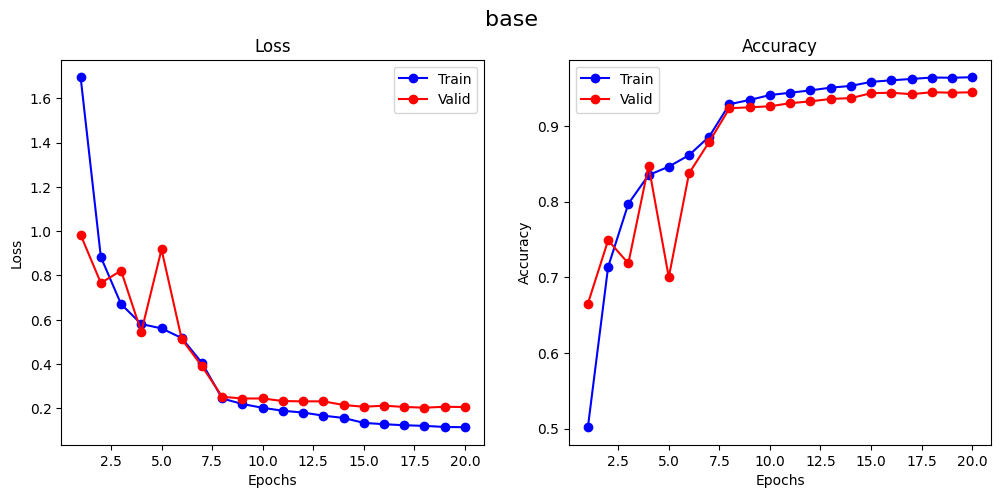

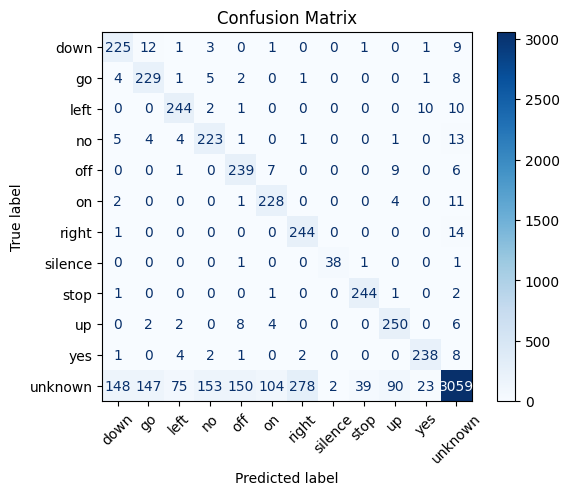

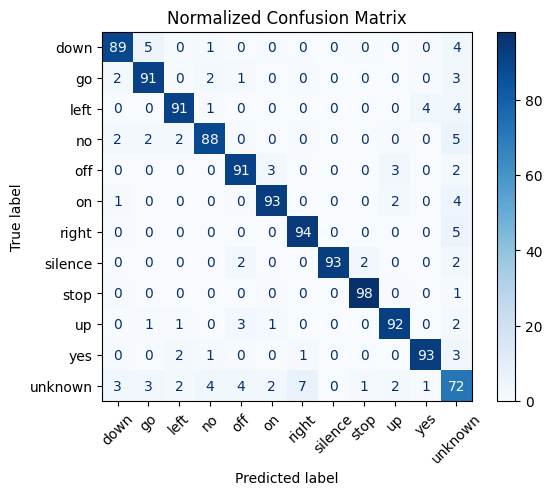

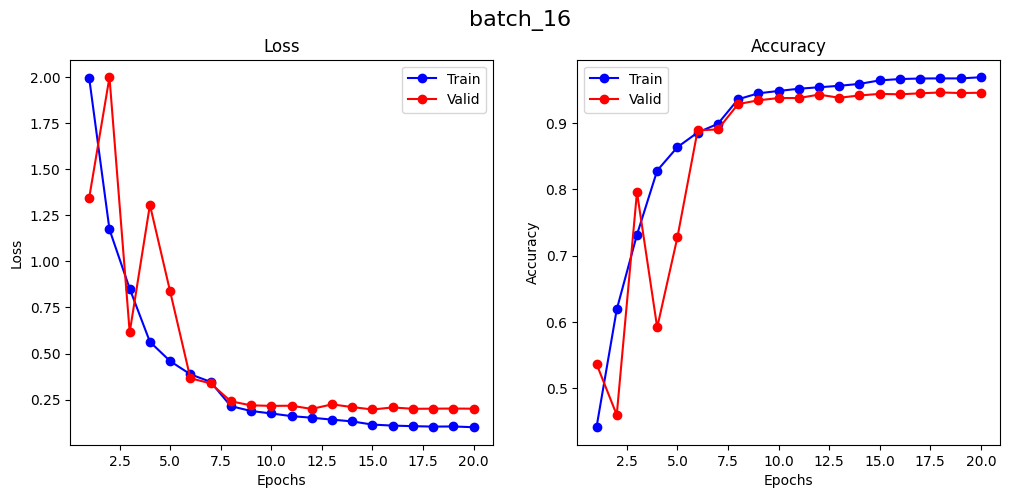

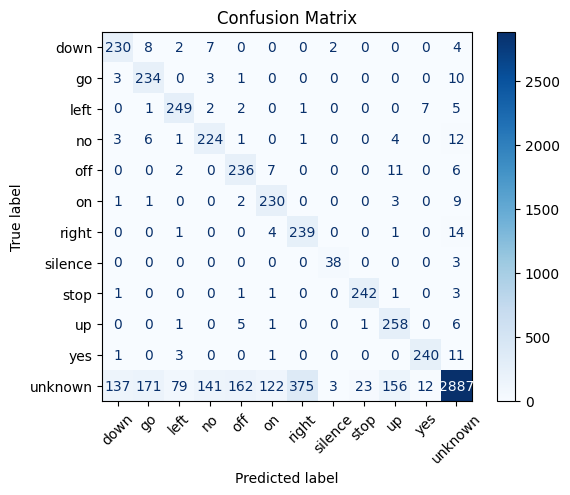

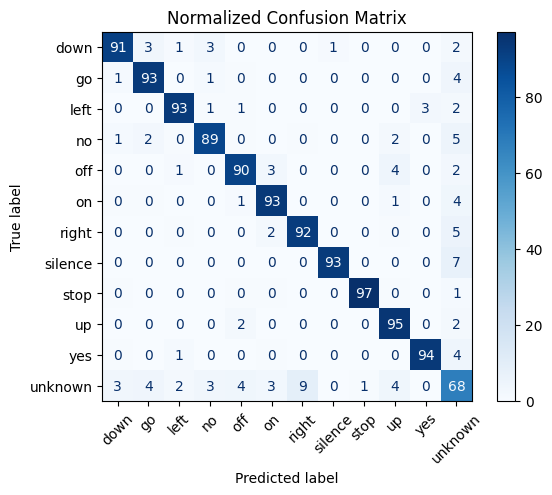

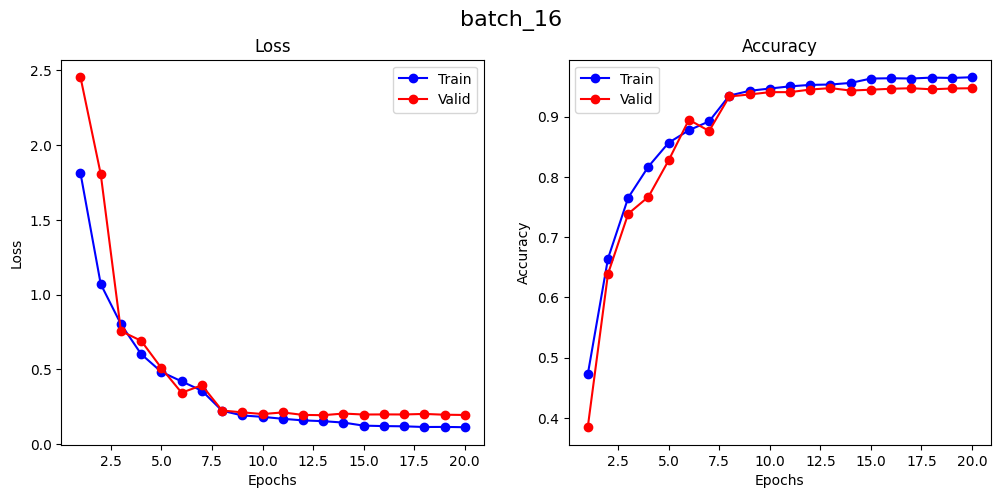

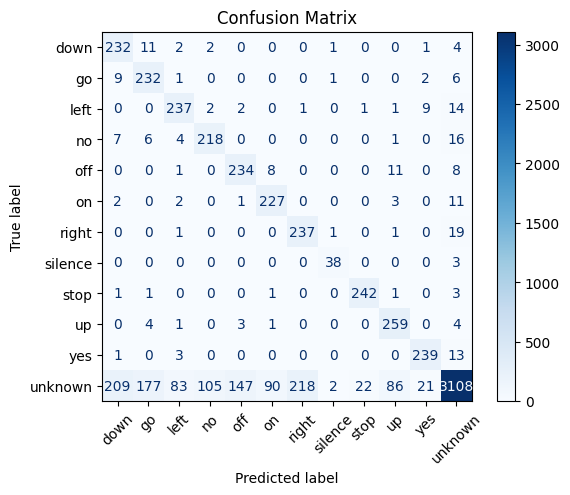

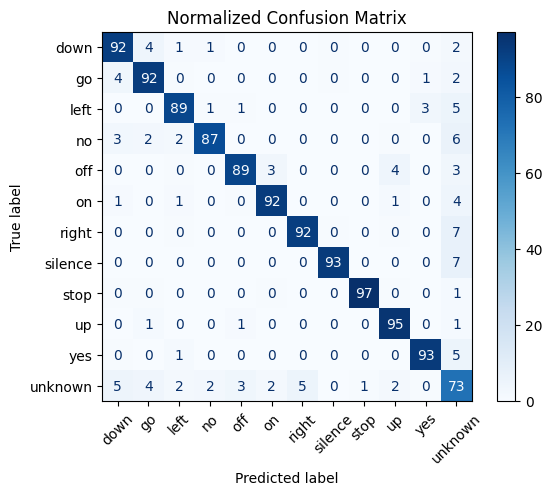

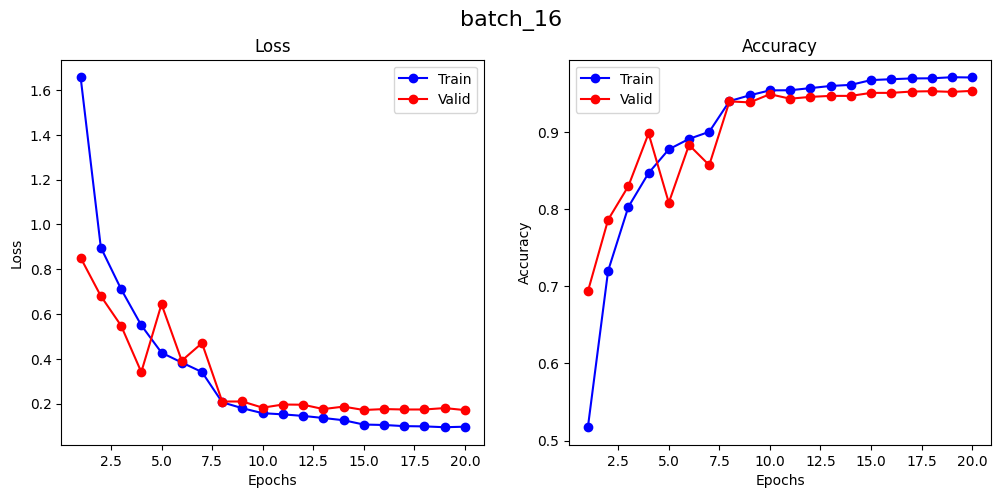

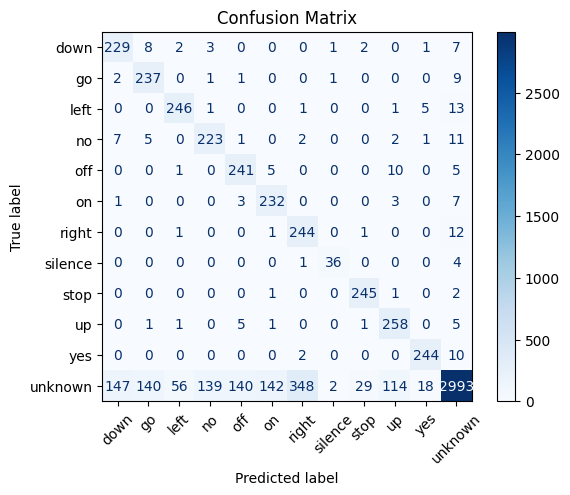

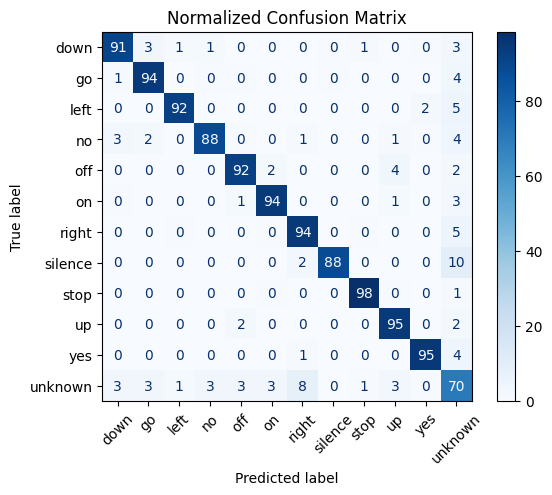

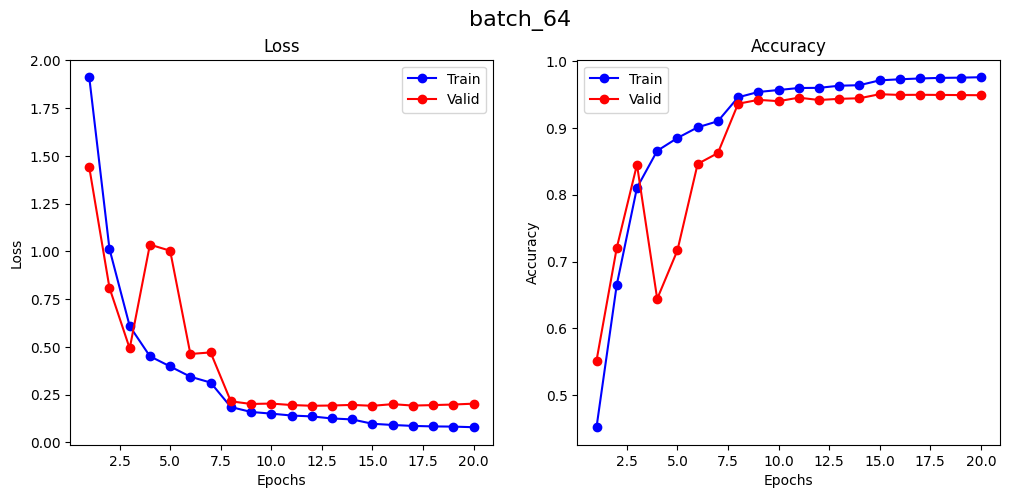

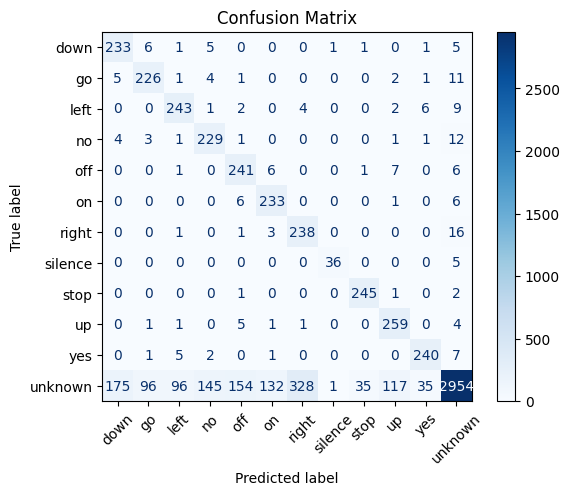

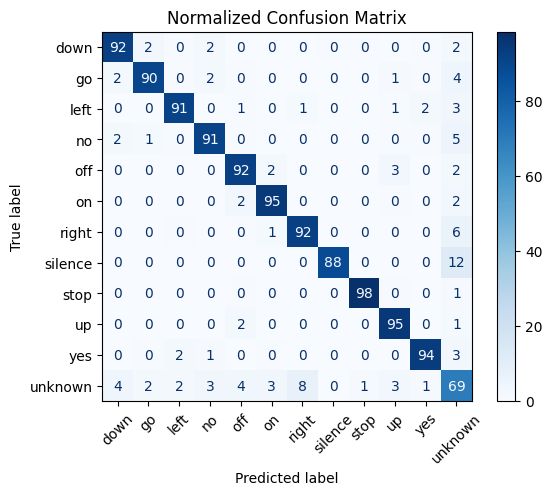

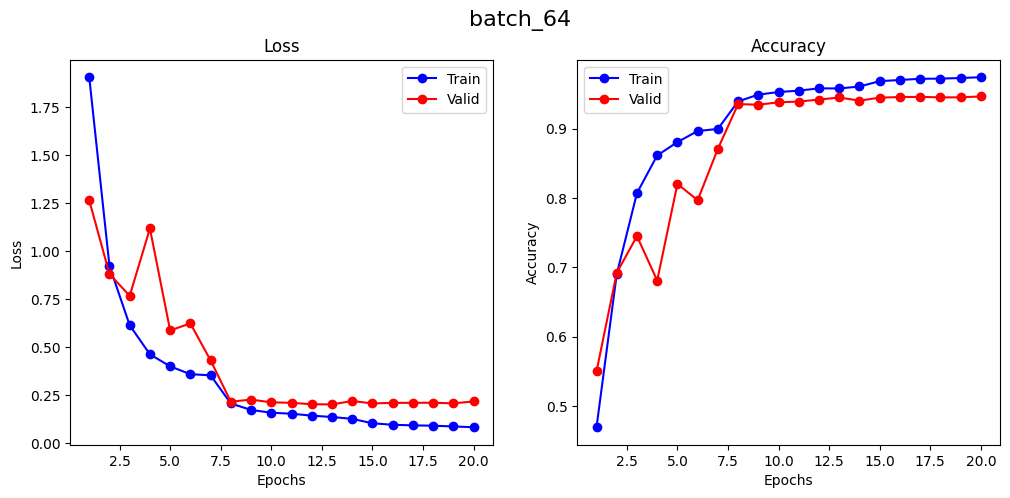

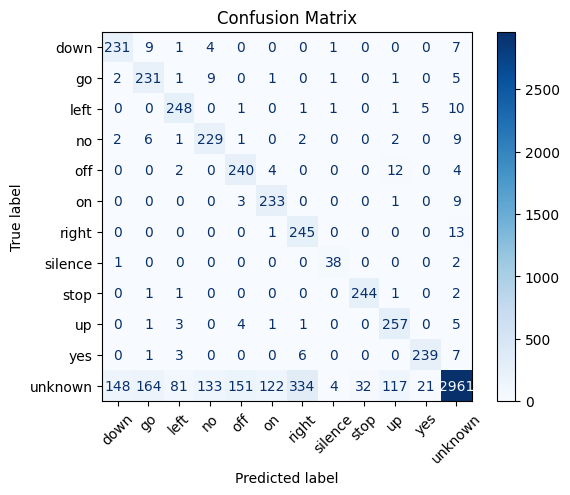

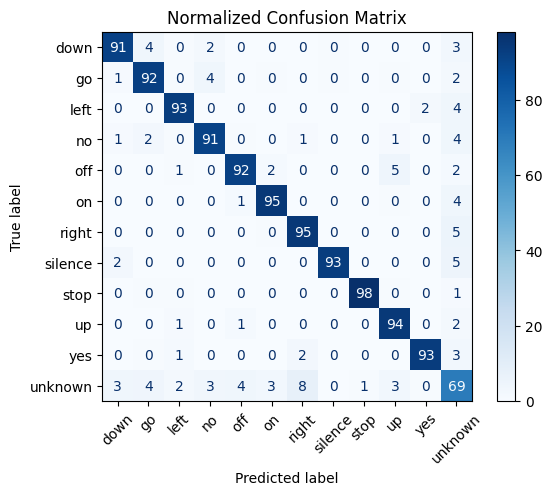

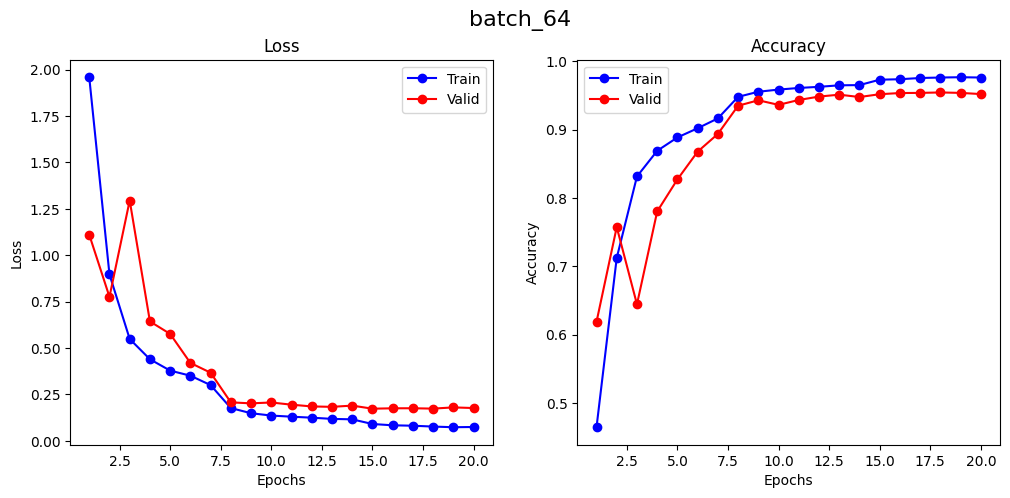

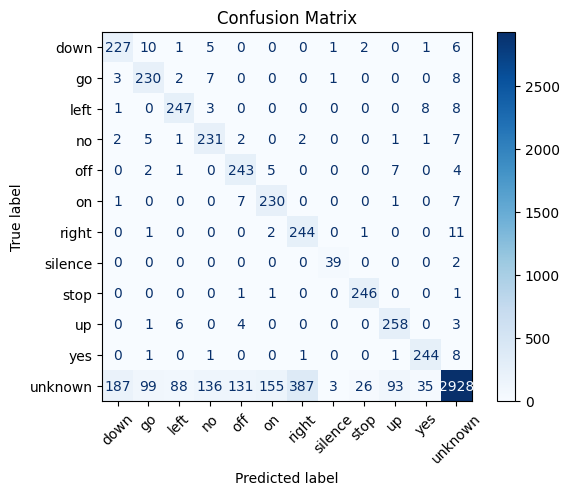

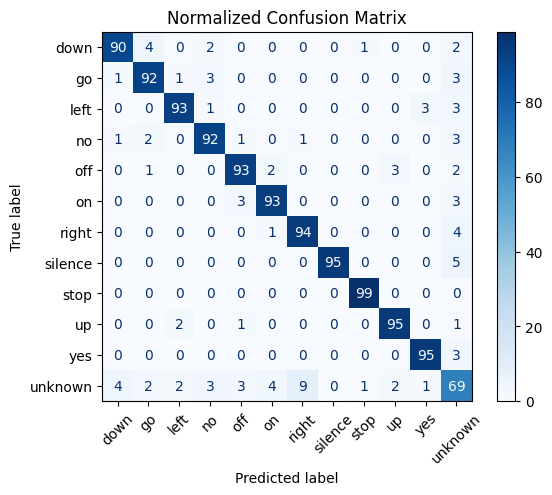

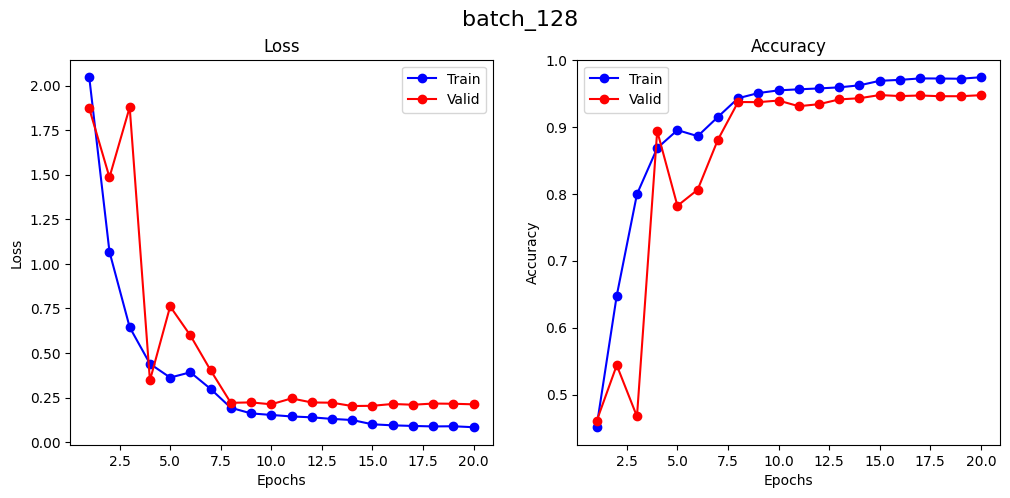

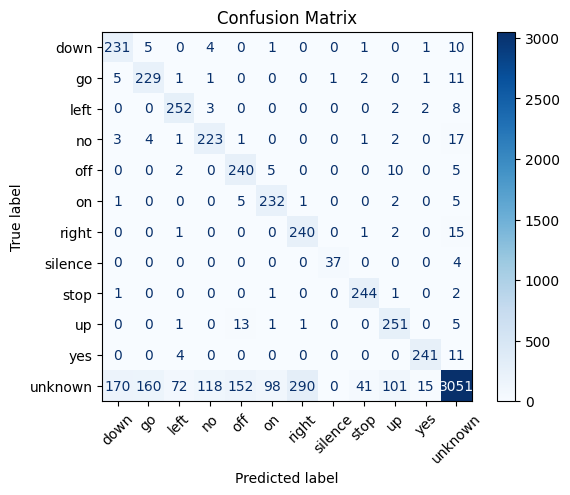

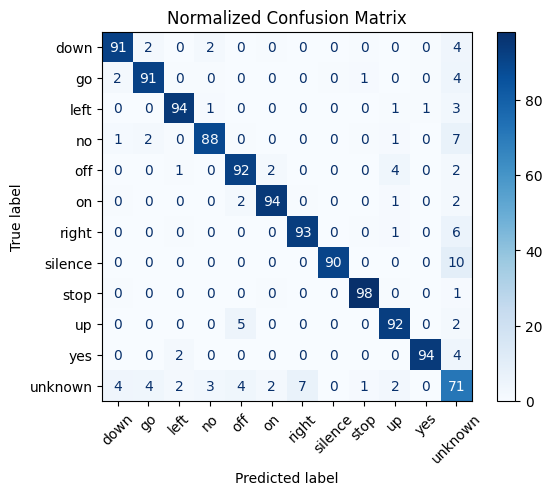

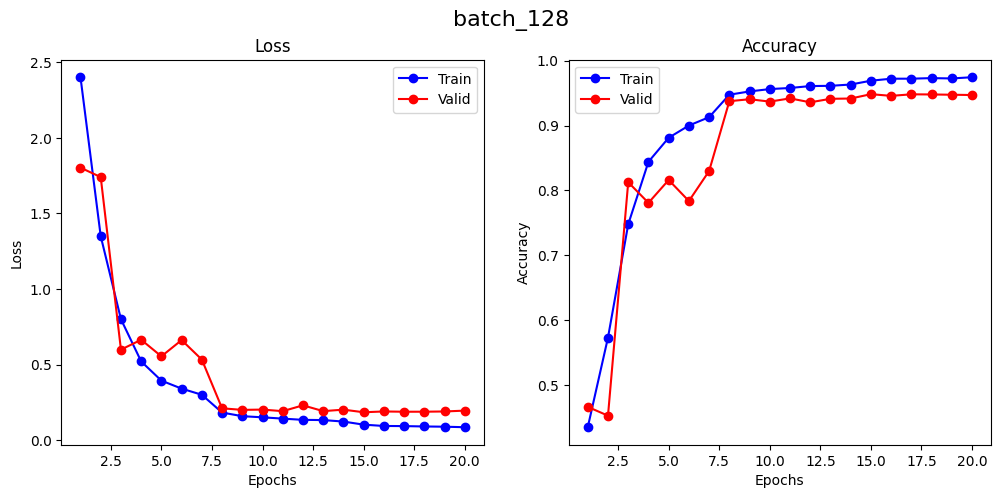

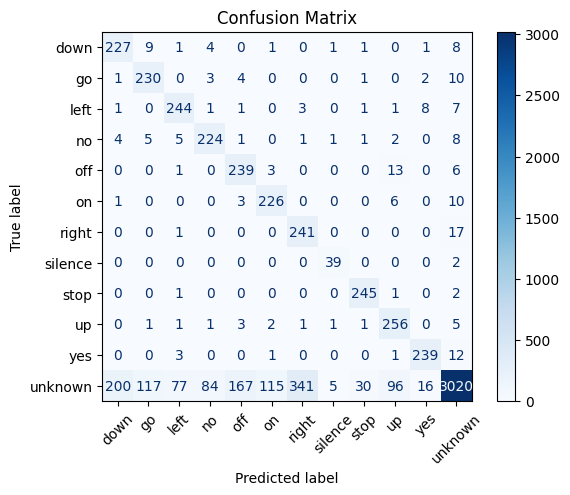

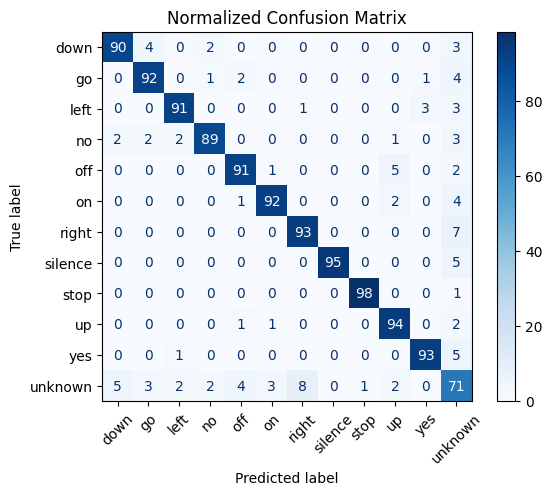

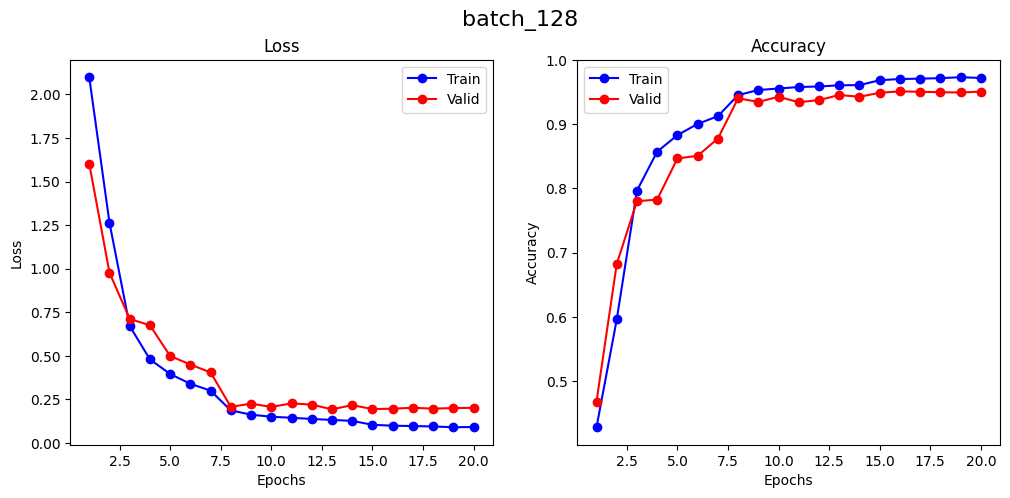

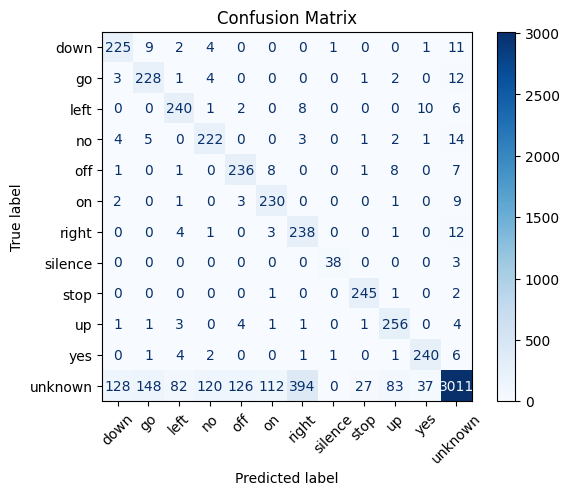

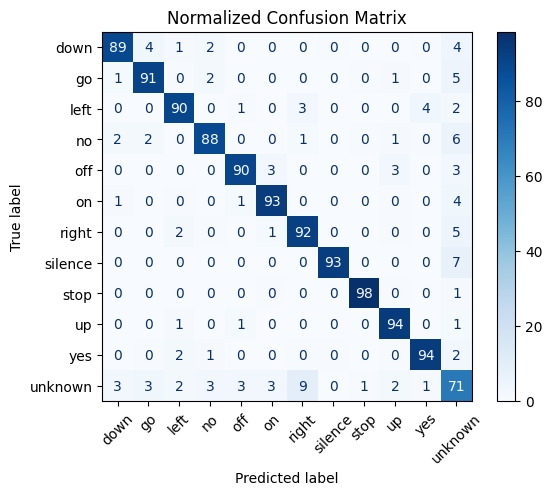

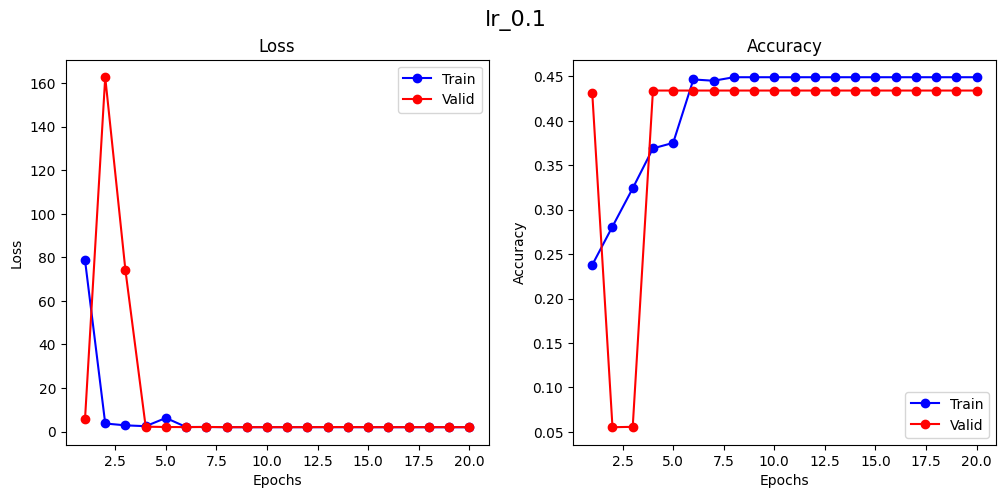

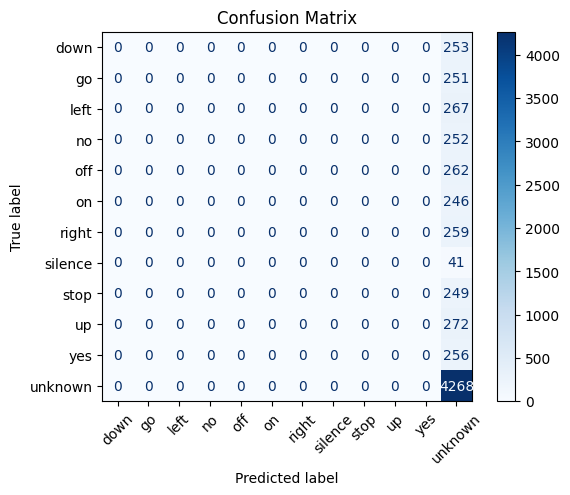

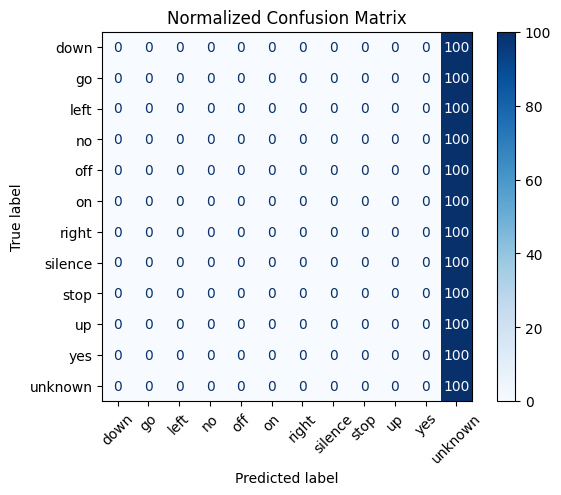

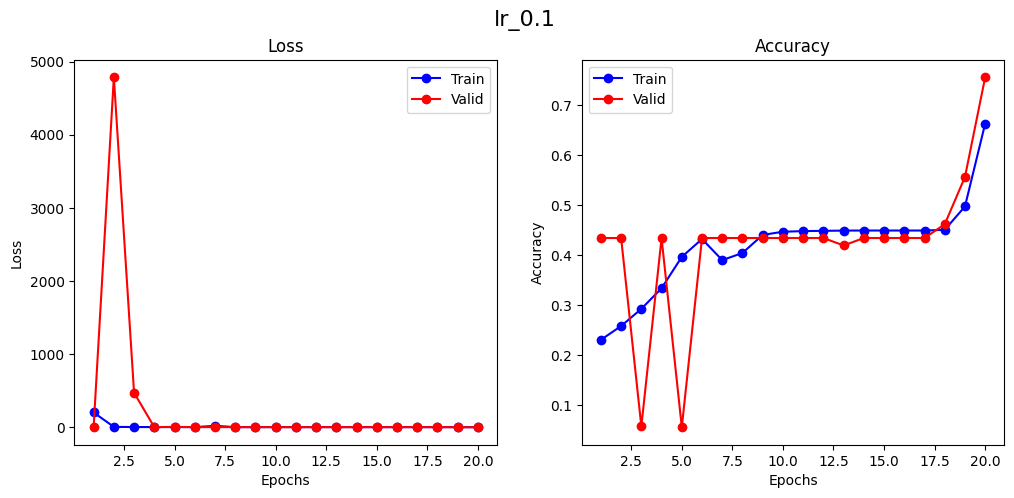

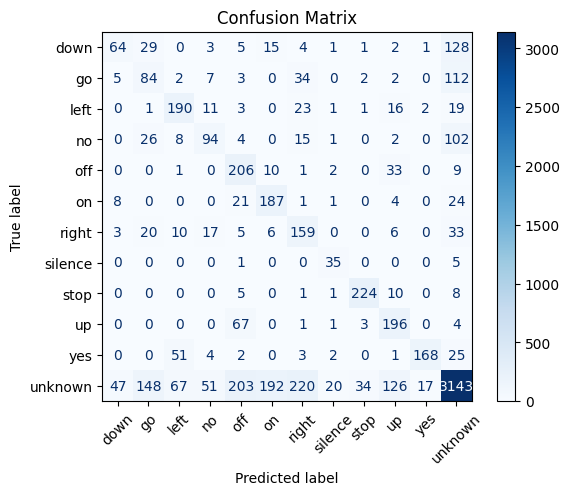

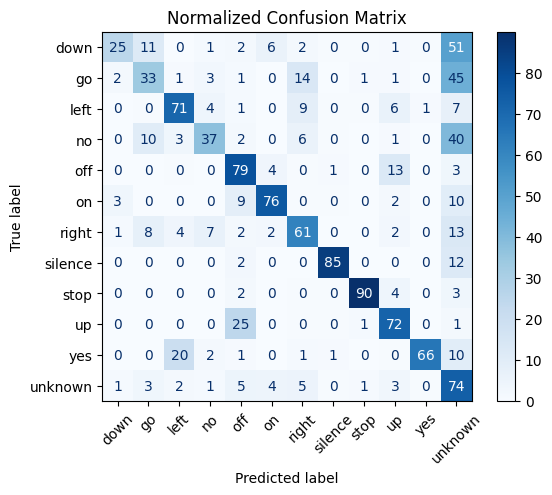

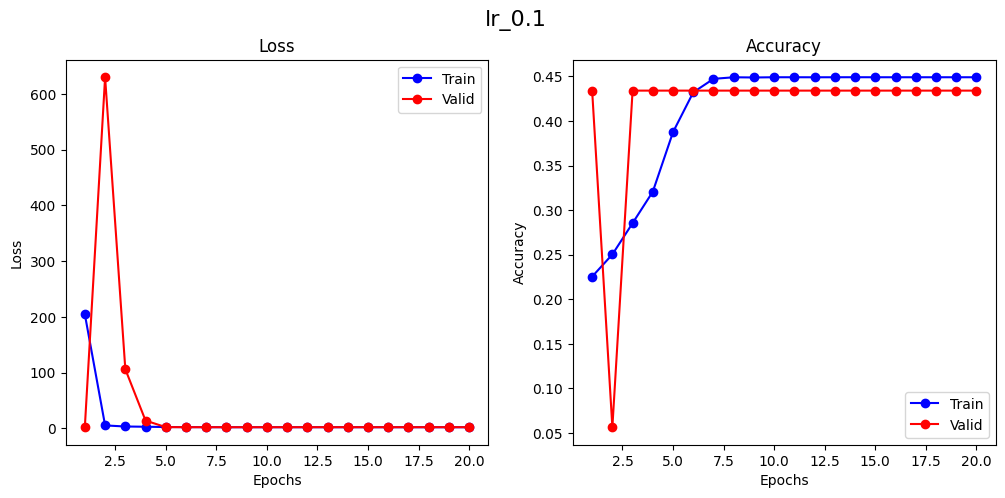

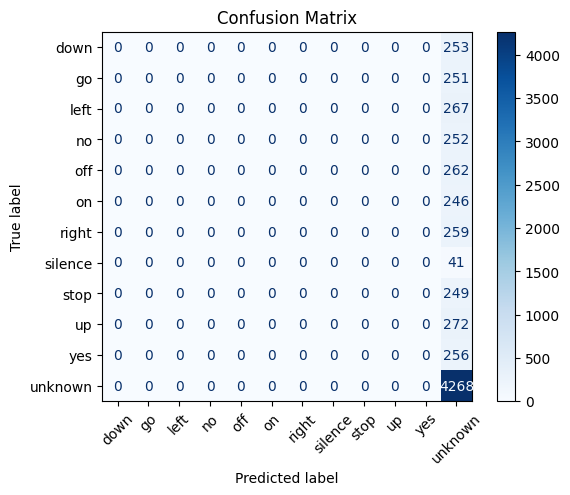

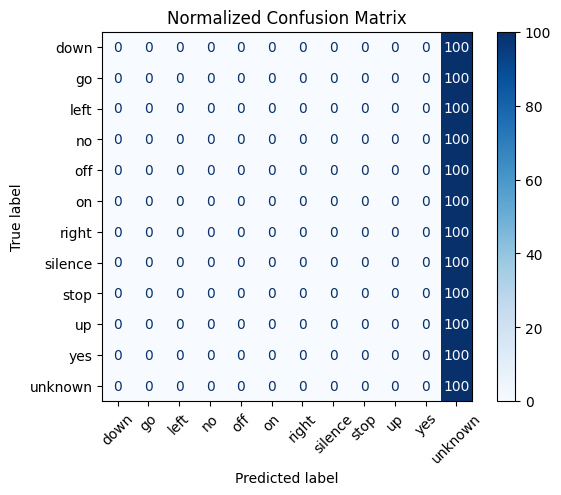

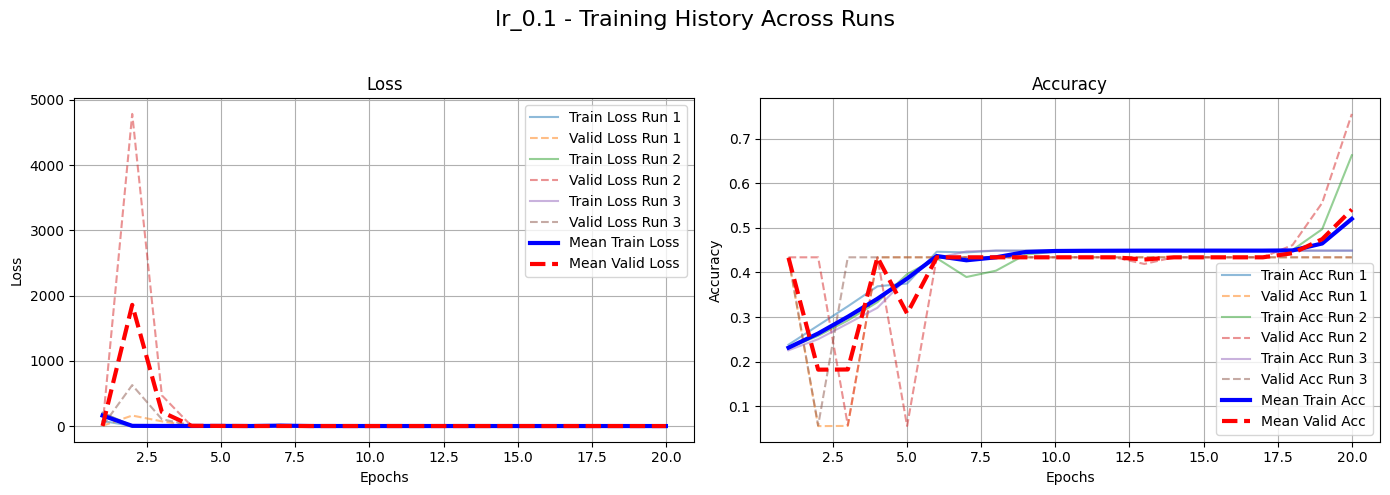

In [ ]:
for config in experiment_configs:

    root_dir = os.path.join('experiments', f'{config['model_type']}_{config['model_name']}')
    os.makedirs(root_dir, exist_ok=True)
    
    all_train_acc_hist = []
    all_val_acc_hist = []
    all_train_loss_hist = []
    all_val_loss_hist = []
    run_accuracies = []

    for i in [42, 24, 62]:

        # Set random seed
        random_seed = i
        random.seed(random_seed)
        torch.manual_seed(random_seed)
        torch.cuda.manual_seed(random_seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
        np.random.seed(random_seed)

        # Load data
        preprocessor = AudioPreprocessor()

        train_dataset = SpeechCommandsDataset(
            root_dir=config['data_dir'],
            file_list_path='train_list.txt',
            mode=config['model_type'],
            preprocessor=preprocessor,
            augment=False
        )

        val_dataset = SpeechCommandsDataset(
            root_dir=config['data_dir'],
            file_list_path='validation_list.txt',
            mode=config['model_type'],
            preprocessor=preprocessor,
            augment=False
        )

        test_dataset = SpeechCommandsDataset(
            root_dir=config['data_dir'],
            file_list_path='testing_list.txt',
            mode=config['model_type'],
            preprocessor=preprocessor,
            augment=False
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=config['batch_size'],
            shuffle=True,
            num_workers=4
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=config['batch_size'],
            shuffle=False,
            num_workers=4
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=config['batch_size'],
            shuffle=True,
            num_workers=4
        )

        dataloaders = {
            'train': train_loader,
            'valid': val_loader,
            'test': test_loader
        }

        # Create model TODO others
        if config['model_type'] == '1d':
            if config['model_name'] == 'vgg':
                model = VGG1D()
            elif config['model_name'] == 'resnet':
                model = resnet34_1d(num_classes=len(class_to_idx))
        else:  # '2d'
            model = get_2d_cnn(config['model_name'], num_classes=len(class_to_idx))

        model = model.to(config['device'])

        # Train model
        criterion = nn.CrossEntropyLoss()

        optimizer = optim.Adam(model.parameters(), 
                            lr=config['learning_rate'], 
                            weight_decay=config['weight_decay'])
        scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

        trained_model, train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist = train_model(
            model=model,
            criterion=criterion,
            optimizer=optimizer,
            scheduler=scheduler,
            dataloaders=dataloaders,
            device=config['device'],
            num_epochs=config['num_epochs']
        )
        
        # Save best model and model details
        folder = os.path.join(os.path.join(root_dir, config['title'].replace('.', '_')), f'rs_{i}')
        os.makedirs(folder, exist_ok=True)

        torch.save(model.state_dict(), os.path.join(folder, 'best_model.pt'))
        
        # Save training history
        plot_training_history(train_loss_hist, train_acc_hist, val_loss_hist, val_acc_hist, config['title'], folder)
        
        # Test model
        test_acc = test_model(model, test_loader, config['device'], folder, 
            ['down', 'go', 'left', 'no', 'off', 'on', 'right', 'silence', 'stop', 'up', 'yes', 'unknown'])
        
        run_accuracies.append(test_acc)
        all_train_acc_hist.append([acc.cpu().numpy() for acc in train_acc_hist])
        all_val_acc_hist.append([acc.cpu().numpy() for acc in val_acc_hist])
        all_train_loss_hist.append([loss for loss in train_loss_hist])
        all_val_loss_hist.append([loss for loss in val_loss_hist])
        
    # Save three runs summary
    
    # Calculate mean and std
    mean_acc = statistics.mean(run_accuracies)
    std_acc = statistics.stdev(run_accuracies)

    summary_file = os.path.join(root_dir, 'summary.xlsx')
    headers = ['Title', 'Batch Size', 'Learning Rate', 'Weight Decay', 'Epochs',
            'Run 1 Accuracy', 'Run 2 Accuracy', 'Run 3 Accuracy', 'Mean Accuracy', 'Std Accuracy']

    row = [
        config['title'],
        config['batch_size'],
        config['learning_rate'],
        config['weight_decay'],
        config['num_epochs'],
        *run_accuracies,
        mean_acc,
        std_acc
    ]

    # Write row to summary.xlsx
    if not os.path.exists(summary_file):
        wb = Workbook()
        ws = wb.active
        ws.append(headers)
    else:
        wb = load_workbook(summary_file)
        ws = wb.active

    ws.append(row)
    wb.save(summary_file)
    
    plot_combined_training_history(all_train_acc_hist, all_val_acc_hist, all_train_loss_hist, all_val_loss_hist,
                                   config['title'], os.path.join(root_dir, config['title']))
    
    matplotlib.pyplot.close()



In [ ]:
# from torchsummary import summary

# summary(model, (1, 16384))

# model = model.to(config['device'])
# sample_input = torch.randn(1, 1, 16384).to(config['device'])
# model.eval()
# with torch.no_grad():
#     output = model(sample_input)
# print(output.shape)
